# 04 - Model Training and Tuning


In [1]:
!uv pip install huggingface_hub webdataset librosa soundfile xgboost statsmodels pyarrow fastparquet

Using Python 3.12.3 environment at: /home/desan/Hackathons/codefest/.venv
Checked 8 packages in 23ms


In [2]:
# ── Section 0-B: imports ──────────────────────────────────────────────────────
import tarfile
import sys, os, re, json, io, time, logging, warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import scipy.signal as ss
import scipy.stats as st
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import soundfile as sf

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("[WARN] XGBoost not available; falling back to HistGradientBoostingClassifier")

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

import webdataset as wds
from huggingface_hub import hf_hub_download, list_repo_files, snapshot_download

import joblib

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Python  : {sys.version}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")
print(f"librosa : {librosa.__version__}")
print(f"sklearn : {__import__('sklearn').__version__}")
if HAS_XGB:
    print(f"xgboost : {xgb.__version__}")

Python  : 3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]
NumPy   : 2.5.3
Pandas  : 3.0.5
librosa : 1.0.0
sklearn : 1.9.0
xgboost : 3.4.1


In [3]:
# ── Section 0-C: global configuration ────────────────────────────────────────
# All tuneable parameters in one place.

RANDOM_SEED   = 42
np.random.seed(RANDOM_SEED)

# Dataset
HF_REPO       = "DesanSilva/sscc-compact-av"
HF_REPO_TYPE  = "dataset"
DATA_DIR      = Path("data/sscc_compact")
OUT_DIR       = Path("outputs")

# Signal parameters (from SSCC spec)
VIB_RATE_HZ       = 100_000     # original acquisition rate
VIB_STORED_HZ     = 10_000      # stored/downsampled rate (compact set)
AUD_RATE_HZ       = 44_100      # recorder (Zoom H5) rate
CLIP_DURATION_S   = 5.0
N_VIB_CHANNELS    = 4

# Feature extraction windows
WINDOW_SIZE_S = 1.0
HOP_SIZE_S    = 0.5

# Vibration frequency bands (Hz) - physically motivated for chain conveyor
VIB_BANDS = {
    "low":    (0,    500),
    "mid":    (500,  2000),
    "high":   (2000, 5000),
}

# Audio frequency bands (Hz)
AUD_BANDS = {
    "sub":    (0,    200),
    "low":    (200,  1000),
    "mid":    (1000, 4000),
    "high":   (4000, 8000),
    "air":    (8000, 16000),
}

# Envelope analysis bandpass (Hz) - mechanical fault region
ENV_BANDPASS_HZ = (500, 4000)

# MFCC
N_MFCC = 13

# Temporal smoothing
EMA_ALPHA     = 0.4
MAVG_WINDOW   = 3
NOM_N         = 3
NOM_M         = 5
PERSIST_K     = 3

# Split sizes
VALID_FRAC = 0.15
TEST_FRAC  = 0.15

# XGBoost / fallback
XGB_ROUNDS        = 500
XGB_EARLY_STOP    = 30
XGB_N_FOLDS       = 5

# Output subdirectories
for sub in ["eda", "features", "models", "metrics", "reports"]:
    (OUT_DIR / sub).mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler()]
)
log = logging.getLogger("sscc_poc")

# Plotting defaults
matplotlib.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
PALETTE = {"normal": "#2ecc71", "dry": "#e74c3c", "lean": "#e67e22",
           "loose": "#9b59b6", "screwdrop": "#3498db"}

print("Configuration complete.")

Configuration complete.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
# Use a clean, professional plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")



In [5]:
import pandas as pd
meta_df = pd.read_parquet(OUT_DIR / '02_prep_state.parquet')
vib_clip_df = pd.read_parquet(OUT_DIR / 'features' / '03_vib_clip.parquet')
aud_clip_df = pd.read_parquet(OUT_DIR / 'features' / '03_aud_clip.parquet')
vib_win_df = pd.read_parquet(OUT_DIR / 'features' / '03_vib_win.parquet')
aud_win_df = pd.read_parquet(OUT_DIR / 'features' / '03_aud_win.parquet')
print('Features loaded successfully.')


Features loaded successfully.


In [6]:
# ── Reload persisted features (if running standalone) ─────────────────────────
# When running the merged notebook top-to-bottom, these are already in memory.
import pandas as pd, numpy as np
from pathlib import Path

OUT_DIR = Path("outputs")

vib_clip_df = pd.read_parquet(OUT_DIR / "features" / "vibration_features.parquet")
aud_clip_df = pd.read_parquet(OUT_DIR / "features" / "audio_features.parquet")
vib_win_df  = pd.read_parquet(OUT_DIR / "features" / "vibration_window_features.parquet")
aud_win_df  = pd.read_parquet(OUT_DIR / "features" / "audio_window_features.parquet")

print(f"vib_clip_df : {vib_clip_df.shape}")
print(f"aud_clip_df : {aud_clip_df.shape}")

vib_clip_df : (288, 893)
aud_clip_df : (288, 605)


---
# 1. Feature Quality Analysis

Before modelling: clean the feature matrix, identify near-zero-variance and highly correlated features, and visualise class separability via PCA.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
import warnings; warnings.filterwarnings("ignore")
import logging
log = logging.getLogger("sscc_poc")

META_COLS = {"sample_id", "fault", "is_fault", "velocity", "source_index",
             "window_idx", "win_start_s", "win_end_s"}

def _feature_cols(df: pd.DataFrame) -> list:
    return [c for c in df.select_dtypes(include=[np.number]).columns
            if c not in META_COLS]


def clean_feature_df(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Remove NaN, inf, zero-variance, and near-constant features."""
    fc = _feature_cols(df)
    X = df[fc].copy()

    # Infinite → NaN → column mean imputation
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    n_inf = X.isnull().sum().sum()
    if n_inf:
        log.warning("%s: %d inf/NaN values imputed with column mean", name, n_inf)
    X = X.fillna(X.mean())

    # Zero variance
    zv_cols = X.columns[X.std() < 1e-10].tolist()
    if zv_cols:
        log.warning("%s: dropping %d zero-variance features", name, len(zv_cols))
        X.drop(columns=zv_cols, inplace=True)

    # Near-zero variance (std < 1% of range)
    near_zv = [c for c in X.columns if X[c].std() < 0.01 * (X[c].max() - X[c].min() + 1e-12)]
    if near_zv:
        log.info("%s: %d near-zero-variance features flagged (kept)", name, len(near_zv))

    print(f"{name}: {X.shape[1]} features remaining after QC")
    return pd.concat([df[list(META_COLS & set(df.columns))], X], axis=1)


vib_clip_df = clean_feature_df(vib_clip_df, "vibration")
aud_clip_df = clean_feature_df(aud_clip_df, "audio")

2026-09-11 22:51:57,311 [WARNING] vibration: dropping 3 zero-variance features


vibration: 885 features remaining after QC
audio: 600 features remaining after QC


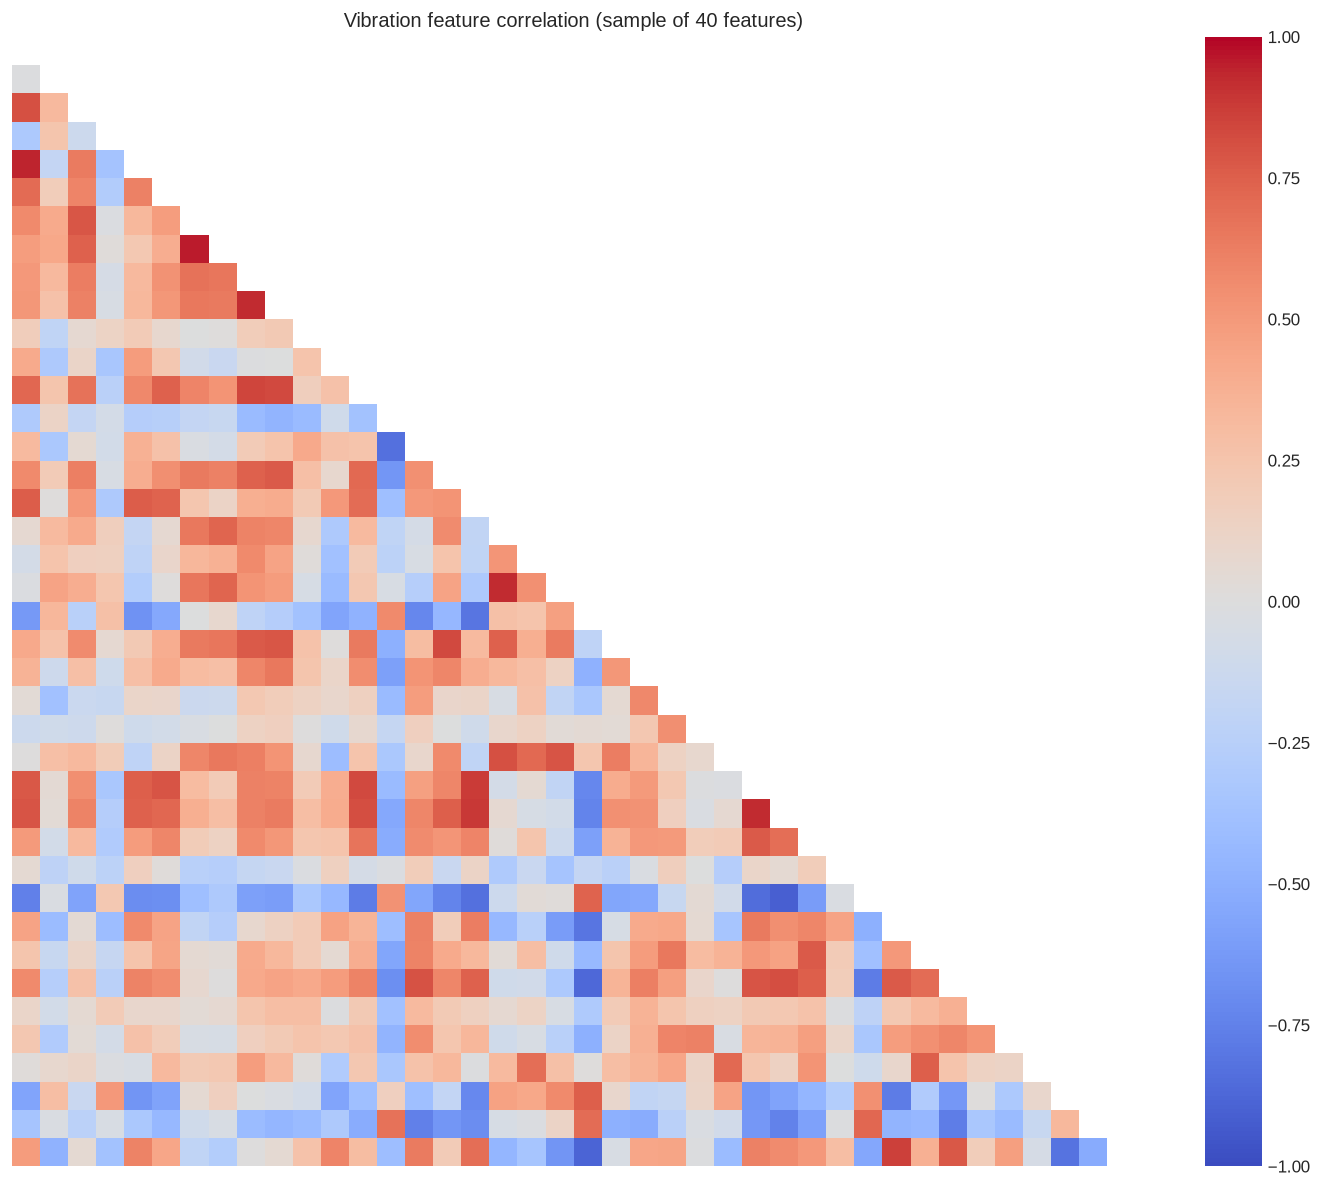

Highly correlated feature pairs (|r|>0.95): 1810


In [8]:
# ── Correlation matrix (sample of features) ───────────────────────────────────

vib_fc = _feature_cols(vib_clip_df)
# Sample 40 features for readability
rng = np.random.default_rng(42)
sample_fc = sorted(rng.choice(vib_fc, size=min(40, len(vib_fc)), replace=False).tolist())

corr = vib_clip_df[sample_fc].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", vmin=-1, vmax=1,
            ax=ax, annot=False, xticklabels=False, yticklabels=False)
ax.set_title("Vibration feature correlation (sample of 40 features)")
plt.tight_layout()
plt.savefig(OUT_DIR / "eda" / "vib_feature_correlation.png", bbox_inches="tight")
plt.show()

# Identify high-correlation pairs
corr_pairs = []
full_corr = vib_clip_df[vib_fc].corr()
for i in range(len(vib_fc)):
    for j in range(i+1, len(vib_fc)):
        c = abs(full_corr.iloc[i, j])
        if c > 0.95:
            corr_pairs.append((vib_fc[i], vib_fc[j], round(c, 3)))
print(f"Highly correlated feature pairs (|r|>0.95): {len(corr_pairs)}")

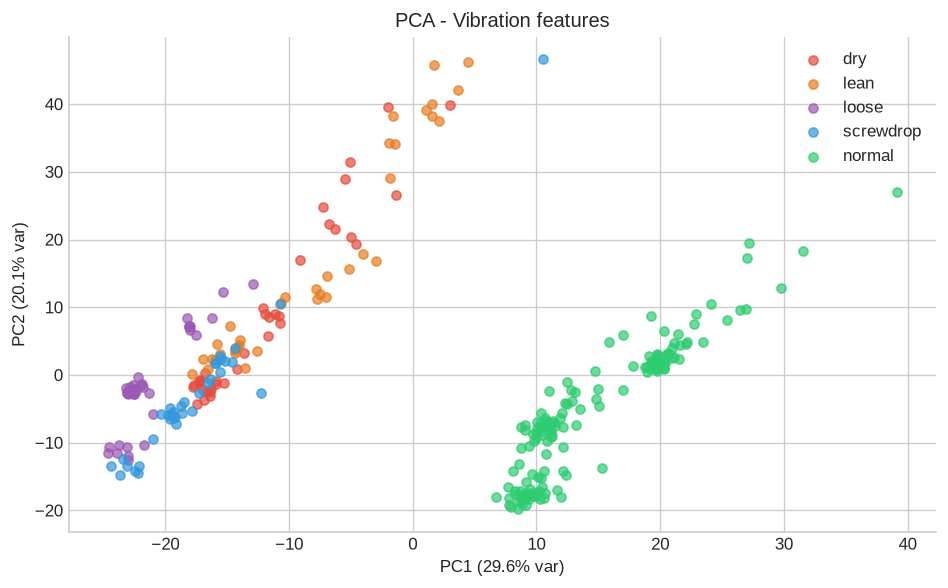

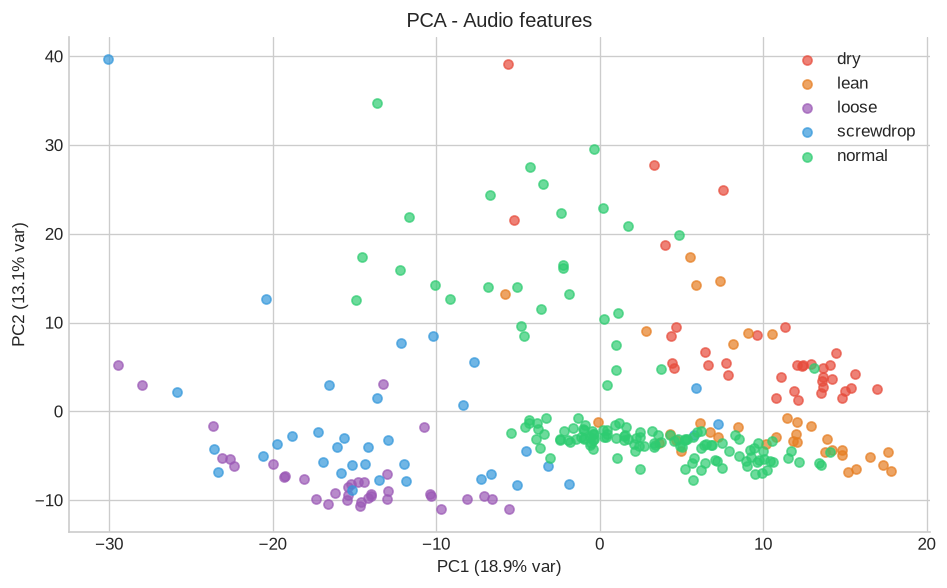

In [9]:
# ── PCA visualisation ─────────────────────────────────────────────────────────

PALETTE = {"normal": "#2ecc71", "dry": "#e74c3c", "lean": "#e67e22",
           "loose": "#9b59b6", "screwdrop": "#3498db"}

def _pca_plot(df: pd.DataFrame, feature_cols: list, title: str, out_name: str) -> None:
    X = df[feature_cols].fillna(0).to_numpy()
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(X_s)
    var_exp = pca.explained_variance_ratio_
    fig, ax = plt.subplots(figsize=(8, 5))
    for ft in df["fault"].unique():
        mask = df["fault"] == ft
        ax.scatter(Z[mask, 0], Z[mask, 1], label=ft,
                   color=PALETTE.get(ft, "grey"), alpha=0.7, s=30)
    ax.set_xlabel(f"PC1 ({var_exp[0]:.1%} var)")
    ax.set_ylabel(f"PC2 ({var_exp[1]:.1%} var)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "eda" / f"{out_name}.png", bbox_inches="tight")
    plt.show()

_pca_plot(vib_clip_df, _feature_cols(vib_clip_df), "PCA - Vibration features", "pca_vibration")
_pca_plot(aud_clip_df, _feature_cols(aud_clip_df), "PCA - Audio features", "pca_audio")

---
# 2. Leakage-Safe Splitting

**Critical rule:** All windows from a single source clip must stay in the same split. We group by `sample_id` (= source clip ID), then perform a stratified split over clips - stratified on `fault` label so class balance is approximately preserved.

The test set is held out until final evaluation. Thresholds and temporal smoothing parameters are tuned on the validation set only.

In [10]:
import random
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
VALID_FRAC  = 0.15
TEST_FRAC   = 0.15

# Work at clip level
clip_ids  = vib_clip_df["sample_id"].to_numpy()
clip_faults = vib_clip_df["fault"].to_numpy()

# Stratified split by fault label
train_val_ids, test_ids = train_test_split(
    clip_ids, test_size=TEST_FRAC,
    stratify=clip_faults, random_state=RANDOM_SEED
)
train_val_faults = vib_clip_df.set_index("sample_id").loc[train_val_ids, "fault"].to_numpy()
val_frac_of_trainval = VALID_FRAC / (1 - TEST_FRAC)

train_ids, val_ids = train_test_split(
    train_val_ids, test_size=val_frac_of_trainval,
    stratify=train_val_faults, random_state=RANDOM_SEED
)

train_set = set(train_ids)
val_set   = set(val_ids)
test_set  = set(test_ids)

assert not (train_set & val_set), "Leakage: train/val overlap"
assert not (train_set & test_set), "Leakage: train/test overlap"
assert not (val_set & test_set), "Leakage: val/test overlap"

def _split_df(df: pd.DataFrame) -> tuple:
    tr = df[df["sample_id"].isin(train_set)].reset_index(drop=True)
    va = df[df["sample_id"].isin(val_set)].reset_index(drop=True)
    te = df[df["sample_id"].isin(test_set)].reset_index(drop=True)
    return tr, va, te

vib_tr, vib_va, vib_te = _split_df(vib_clip_df)
aud_tr, aud_va, aud_te = _split_df(aud_clip_df)

print(f"Clip split: train={len(train_ids)}  val={len(val_ids)}  test={len(test_ids)}")
for name, split_df in [("train", vib_tr), ("val", vib_va), ("test", vib_te)]:
    print(f"  {name}: {split_df['fault'].value_counts().to_dict()}")

Clip split: train=200  val=44  test=44
  train: {'normal': 100, 'dry': 25, 'lean': 25, 'loose': 25, 'screwdrop': 25}
  val: {'normal': 22, 'lean': 6, 'screwdrop': 6, 'dry': 5, 'loose': 5}
  test: {'normal': 22, 'dry': 6, 'loose': 6, 'lean': 5, 'screwdrop': 5}


In [11]:
# ── Build X/y arrays and scale ────────────────────────────────────────────────

def _Xy(df: pd.DataFrame, feat_cols: list, label: str = "is_fault") -> tuple:
    X = df[feat_cols].fillna(0).to_numpy().astype(np.float32)
    y = df[label].to_numpy()
    return X, y

def _Xy_mc(df: pd.DataFrame, feat_cols: list) -> tuple:
    """Multiclass - fault type, abnormal samples only."""
    ab = df[df["is_fault"] == 1]
    X = ab[feat_cols].fillna(0).to_numpy().astype(np.float32)
    y = ab["fault"].to_numpy()
    return X, y

vib_fc = _feature_cols(vib_clip_df)
aud_fc = _feature_cols(aud_clip_df)

# Scaler fit on training data only
vib_scaler = StandardScaler().fit(vib_tr[vib_fc].fillna(0))
aud_scaler = StandardScaler().fit(aud_tr[aud_fc].fillna(0))

joblib.dump(vib_scaler, OUT_DIR / "models" / "vib_scaler.pkl")
joblib.dump(aud_scaler, OUT_DIR / "models" / "aud_scaler.pkl")

def _scale_vib(df: pd.DataFrame) -> np.ndarray:
    return vib_scaler.transform(df[vib_fc].fillna(0)).astype(np.float32)

def _scale_aud(df: pd.DataFrame) -> np.ndarray:
    return aud_scaler.transform(df[aud_fc].fillna(0)).astype(np.float32)

print(f"Vibration features : {len(vib_fc)}")
print(f"Audio features     : {len(aud_fc)}")
print("Scalers saved.")

Vibration features : 885
Audio features     : 600
Scalers saved.


---
# 3. Classifier Helpers and Training Functions

We define:
- `build_classifier()` - returns an XGBoost or fallback classifier
- `train_binary()` - trains with eval set and returns training curve
- `evaluate_binary()` - computes all required metrics
- `evaluate_multiclass()` - multiclass metrics including per-class recall

In [12]:
import joblib
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
)
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

XGB_ROUNDS     = 500
XGB_EARLY_STOP = 30
XGB_N_FOLDS    = 5

def build_xgb_binary(n_pos: int, n_neg: int, seed: int = 42) -> object:
    scale_pos = n_neg / (n_pos + 1e-6)
    if HAS_XGB:
        return xgb.XGBClassifier(
            n_estimators=XGB_ROUNDS, learning_rate=0.05,
            max_depth=5, subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos, eval_metric="logloss",
            early_stopping_rounds=XGB_EARLY_STOP,
            use_label_encoder=False, random_state=seed, n_jobs=-1,
        )
    return HistGradientBoostingClassifier(
        max_iter=XGB_ROUNDS, learning_rate=0.05,
        max_depth=5, random_state=seed,
        class_weight={0: 1, 1: scale_pos},
    )


def build_xgb_mc(n_classes: int, seed: int = 42) -> object:
    if HAS_XGB:
        return xgb.XGBClassifier(
            n_estimators=XGB_ROUNDS, learning_rate=0.05,
            max_depth=5, subsample=0.8, colsample_bytree=0.8,
            objective="multi:softprob", num_class=n_classes,
            eval_metric="mlogloss",
            early_stopping_rounds=XGB_EARLY_STOP,
            use_label_encoder=False, random_state=seed, n_jobs=-1,
        )
    from sklearn.ensemble import HistGradientBoostingClassifier
    return HistGradientBoostingClassifier(
        max_iter=XGB_ROUNDS, learning_rate=0.05,
        max_depth=5, random_state=seed,
    )


def train_binary_xgb(
    X_tr: np.ndarray, y_tr: np.ndarray,
    X_va: np.ndarray, y_va: np.ndarray,
    name: str,
) -> Tuple:
    """Train XGBoost binary classifier; return (model, evals_result)."""
    n_pos = int(y_tr.sum())
    n_neg = int((y_tr == 0).sum())
    clf = build_xgb_binary(n_pos, n_neg)
    if HAS_XGB:
        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_tr, y_tr), (X_va, y_va)],
            verbose=False,
        )
        evals = clf.evals_result()
    else:
        clf.fit(X_tr, y_tr)
        evals = {}
    joblib.dump(clf, OUT_DIR / "models" / f"{name}.pkl")
    return clf, evals


def plot_training_curves(evals: dict, name: str) -> None:
    if not evals:
        print(f"[SKIP] No training curve data for {name}")
        return
    keys = list(evals.keys())  # e.g. ['validation_0', 'validation_1']
    metric = list(evals[keys[0]].keys())[0]
    fig, ax = plt.subplots(figsize=(8, 3))
    labels = ["Train", "Validation"]
    for ki, key in enumerate(keys[:2]):
        vals = evals[key][metric]
        ax.plot(vals, label=labels[ki])
    ax.set_xlabel("Boosting round")
    ax.set_ylabel(metric)
    ax.set_title(f"Training curve - {name}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "eda" / f"training_curve_{name}.png", bbox_inches="tight")
    plt.show()


def evaluate_binary(
    clf, X: np.ndarray, y: np.ndarray,
    threshold: float = 0.5, name: str = "",
) -> dict:
    """Compute binary classification metrics."""
    prob = clf.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)
    cm   = confusion_matrix(y, pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    specificity = tn / (tn + fp + 1e-12)

    n_classes_in_y = len(np.unique(y))
    roc_auc = roc_auc_score(y, prob) if n_classes_in_y == 2 else float("nan")
    pr_auc  = average_precision_score(y, prob) if n_classes_in_y == 2 else float("nan")

    return {
        "name":        name,
        "threshold":   threshold,
        "accuracy":    accuracy_score(y, pred),
        "precision":   precision_score(y, pred, zero_division=0),
        "recall":      recall_score(y, pred, zero_division=0),
        "specificity": specificity,
        "f1":          f1_score(y, pred, zero_division=0),
        "roc_auc":     roc_auc,
        "pr_auc":      pr_auc,
        "confusion_matrix": cm,
        "prob":        prob,
        "pred":        pred,
    }


def evaluate_multiclass(
    clf, X: np.ndarray, y_str: np.ndarray, le,
    name: str = "",
) -> dict:
    """Multiclass metrics."""
    y = le.transform(y_str)
    prob = clf.predict_proba(X)
    pred_enc = clf.predict(X)
    pred_str = le.inverse_transform(pred_enc)
    classes  = le.classes_

    mc_roc = float("nan")
    if len(np.unique(y)) > 1:
        try:
            mc_roc = roc_auc_score(y, prob, multi_class="ovr", average="macro")
        except Exception:
            pass

    return {
        "name":            name,
        "accuracy":        accuracy_score(y, pred_enc),
        "macro_precision": precision_score(y, pred_enc, average="macro", zero_division=0),
        "macro_recall":    recall_score(y, pred_enc, average="macro", zero_division=0),
        "macro_f1":        f1_score(y, pred_enc, average="macro", zero_division=0),
        "weighted_f1":     f1_score(y, pred_enc, average="weighted", zero_division=0),
        "roc_auc_ovr":     mc_roc,
        "confusion_matrix":confusion_matrix(y, pred_enc),
        "classes":         classes,
        "pred_str":        pred_str,
        "y_str":           y_str,
        "prob":            prob,
    }


def plot_confusion(cm: np.ndarray, labels: list, title: str, out_name: str) -> None:
    fig, ax = plt.subplots(figsize=(max(4, len(labels)), max(3, len(labels))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "eda" / f"{out_name}.png", bbox_inches="tight")
    plt.show()


def plot_roc_pr(metrics: dict, title: str, out_name: str) -> None:
    y_true = metrics.get("y_true")
    prob   = metrics["prob"]
    if y_true is None or np.isnan(metrics["roc_auc"]):
        print(f"[SKIP ROC] {title}")
        return
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fpr, tpr, _ = roc_curve(y_true, prob)
    axes[0].plot(fpr, tpr, lw=1.5, label=f"AUC={metrics['roc_auc']:.3f}")
    axes[0].plot([0,1],[0,1],"--",color="grey")
    axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
    axes[0].set_title(f"ROC - {title}"); axes[0].legend()

    prec, rec, _ = precision_recall_curve(y_true, prob)
    axes[1].plot(rec, prec, lw=1.5, label=f"AP={metrics['pr_auc']:.3f}")
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title(f"PR - {title}"); axes[1].legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "eda" / f"roc_pr_{out_name}.png", bbox_inches="tight")
    plt.show()


print("Classifier and evaluation helpers defined.")

Classifier and evaluation helpers defined.


---
# 4. Baseline 1: Vibration-Only


In [13]:
# ── Section 15-A: Logistic Regression baseline ─────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

X_vib_tr = _scale_vib(vib_tr); y_tr_bin = vib_tr["is_fault"].to_numpy()
X_vib_va = _scale_vib(vib_va); y_va_bin = vib_va["is_fault"].to_numpy()
X_vib_te = _scale_vib(vib_te); y_te_bin = vib_te["is_fault"].to_numpy()

lr_vib = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_vib.fit(X_vib_tr, y_tr_bin)
joblib.dump(lr_vib, OUT_DIR / "models" / "lr_vibration.pkl")

lr_va_metrics = evaluate_binary(lr_vib, X_vib_va, y_va_bin, name="LR_Vib_Val")
lr_va_metrics["y_true"] = y_va_bin
print(f"LR Vibration (val): Acc={lr_va_metrics['accuracy']:.3f}  "
      f"Rec={lr_va_metrics['recall']:.3f}  F1={lr_va_metrics['f1']:.3f}  "
      f"AUC={lr_va_metrics['roc_auc']:.3f}")

LR Vibration (val): Acc=1.000  Rec=1.000  F1=1.000  AUC=1.000


In [14]:
# ── Section 15-B: Random Forest ───────────────────────────────────────────────
rf_vib = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                 random_state=42, n_jobs=-1)
rf_vib.fit(X_vib_tr, y_tr_bin)
joblib.dump(rf_vib, OUT_DIR / "models" / "rf_vibration.pkl")

rf_va_metrics = evaluate_binary(rf_vib, X_vib_va, y_va_bin, name="RF_Vib_Val")
rf_va_metrics["y_true"] = y_va_bin
print(f"RF Vibration  (val): Acc={rf_va_metrics['accuracy']:.3f}  "
      f"Rec={rf_va_metrics['recall']:.3f}  F1={rf_va_metrics['f1']:.3f}  "
      f"AUC={rf_va_metrics['roc_auc']:.3f}")

RF Vibration  (val): Acc=1.000  Rec=1.000  F1=1.000  AUC=1.000


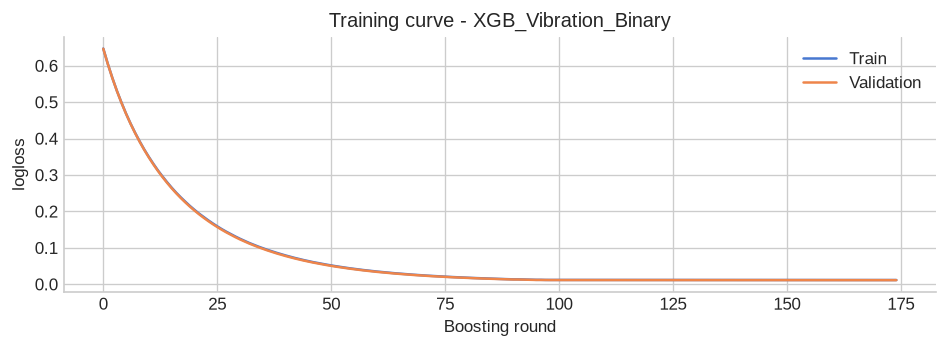

XGB Vibration (val): Acc=1.000  Rec=1.000  F1=1.000  AUC=1.000


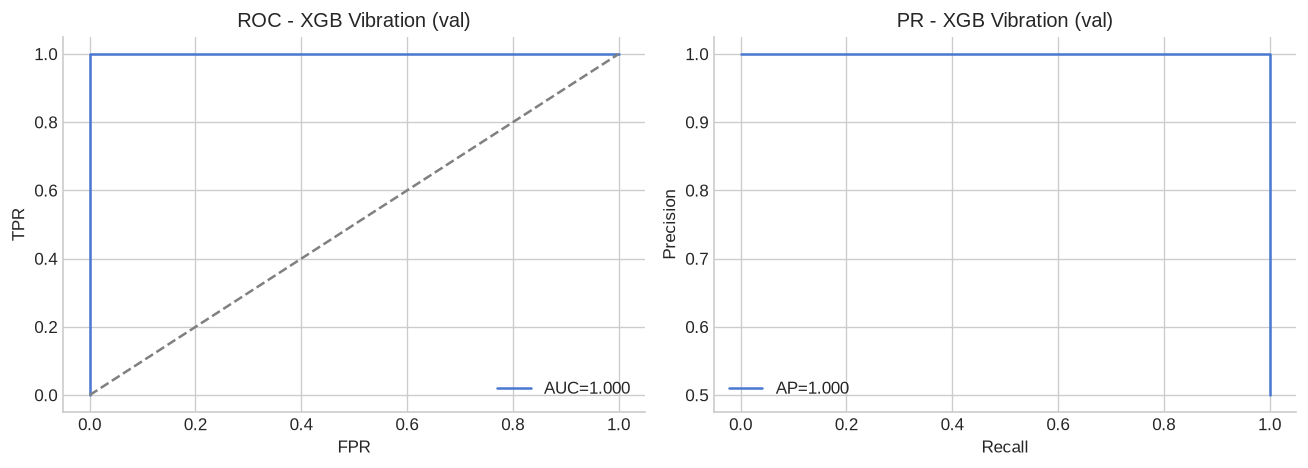

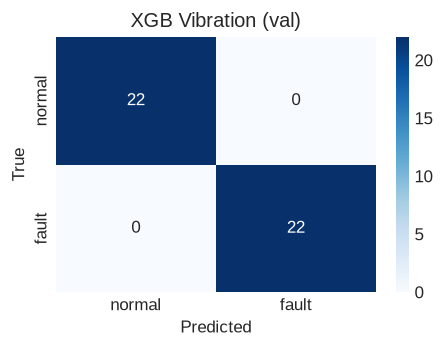

In [15]:
# ── Section 15-C: XGBoost vibration binary ────────────────────────────────────
xgb_vib_bin, evals_vib_bin = train_binary_xgb(
    X_vib_tr, y_tr_bin, X_vib_va, y_va_bin, "xgb_vibration_binary"
)
plot_training_curves(evals_vib_bin, "XGB_Vibration_Binary")

xgb_vib_va = evaluate_binary(xgb_vib_bin, X_vib_va, y_va_bin, name="XGB_Vib_Val")
xgb_vib_va["y_true"] = y_va_bin
print(f"XGB Vibration (val): Acc={xgb_vib_va['accuracy']:.3f}  "
      f"Rec={xgb_vib_va['recall']:.3f}  F1={xgb_vib_va['f1']:.3f}  "
      f"AUC={xgb_vib_va['roc_auc']:.3f}")

plot_roc_pr(xgb_vib_va, "XGB Vibration (val)", "xgb_vib_binary_val")
plot_confusion(xgb_vib_va["confusion_matrix"], ["normal","fault"],
               "XGB Vibration (val)", "cm_xgb_vib_binary_val")

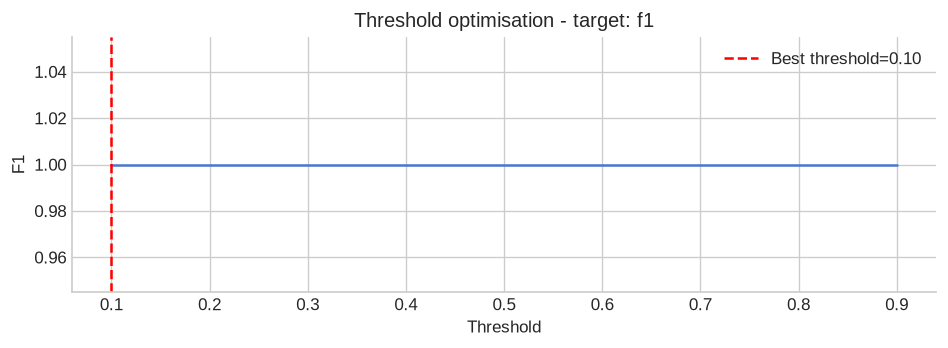

Best validation threshold (vibration): 0.10


In [16]:
# ── Section 15-D: threshold optimisation on validation set ────────────────────

def find_best_threshold(clf, X_va: np.ndarray, y_va: np.ndarray,
                         target: str = "f1") -> float:
    """Sweep thresholds; return threshold maximising target metric on val set."""
    prob = clf.predict_proba(X_va)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 81)
    scores = []
    for th in thresholds:
        pred = (prob >= th).astype(int)
        scores.append(f1_score(y_va, pred, zero_division=0))
    best_idx = int(np.argmax(scores))
    best_th  = float(thresholds[best_idx])

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(thresholds, scores, lw=1.5)
    ax.axvline(best_th, ls="--", color="red", label=f"Best threshold={best_th:.2f}")
    ax.set_xlabel("Threshold"); ax.set_ylabel("F1")
    ax.set_title(f"Threshold optimisation - target: {target}")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return best_th


best_th_vib = find_best_threshold(xgb_vib_bin, X_vib_va, y_va_bin)
print(f"Best validation threshold (vibration): {best_th_vib:.2f}")

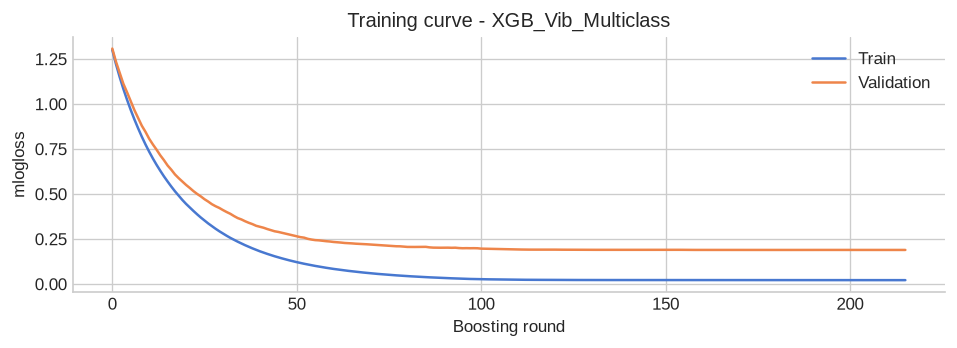

XGB Vibration MC (val): Acc=0.955  Macro-F1=0.953  AUC=0.997
              precision    recall  f1-score   support

         dry       1.00      0.80      0.89         5
        lean       0.86      1.00      0.92         6
       loose       1.00      1.00      1.00         5
   screwdrop       1.00      1.00      1.00         6

    accuracy                           0.95        22
   macro avg       0.96      0.95      0.95        22
weighted avg       0.96      0.95      0.95        22



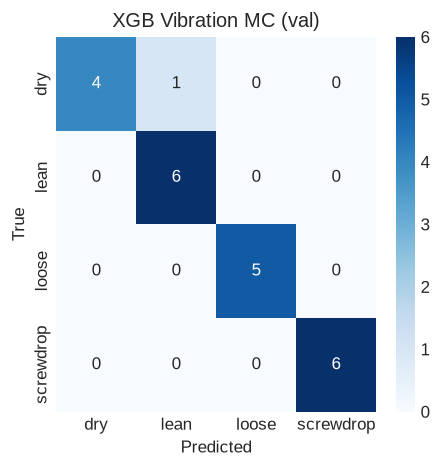

In [17]:
# ── Section 15-E: vibration multiclass ───────────────────────────────────────
le_mc = LabelEncoder()
fault_types = sorted(vib_tr[vib_tr["is_fault"]==1]["fault"].unique())
le_mc.fit(fault_types)

vib_tr_ab = vib_tr[vib_tr["is_fault"]==1]
vib_va_ab = vib_va[vib_va["is_fault"]==1]

X_vib_tr_ab = _scale_vib(vib_tr_ab)
X_vib_va_ab = _scale_vib(vib_va_ab)
y_tr_mc = le_mc.transform(vib_tr_ab["fault"].to_numpy())
y_va_mc = le_mc.transform(vib_va_ab["fault"].to_numpy())

xgb_vib_mc = build_xgb_mc(len(fault_types))
if HAS_XGB:
    xgb_vib_mc.fit(
        X_vib_tr_ab, y_tr_mc,
        eval_set=[(X_vib_tr_ab, y_tr_mc), (X_vib_va_ab, y_va_mc)],
        verbose=False,
    )
    plot_training_curves(xgb_vib_mc.evals_result(), "XGB_Vib_Multiclass")
else:
    xgb_vib_mc.fit(X_vib_tr_ab, y_tr_mc)

joblib.dump(xgb_vib_mc, OUT_DIR / "models" / "xgb_vibration_mc.pkl")

vib_mc_va = evaluate_multiclass(xgb_vib_mc, X_vib_va_ab, vib_va_ab["fault"].to_numpy(), le_mc, name="XGB_Vib_MC_Val")
print(f"XGB Vibration MC (val): Acc={vib_mc_va['accuracy']:.3f}  "
      f"Macro-F1={vib_mc_va['macro_f1']:.3f}  AUC={vib_mc_va['roc_auc_ovr']:.3f}")
print(classification_report(vib_mc_va["y_str"], vib_mc_va["pred_str"], zero_division=0))
plot_confusion(vib_mc_va["confusion_matrix"], list(le_mc.classes_),
               "XGB Vibration MC (val)", "cm_xgb_vib_mc_val")

---
# 5. Baseline 2: Audio-Only


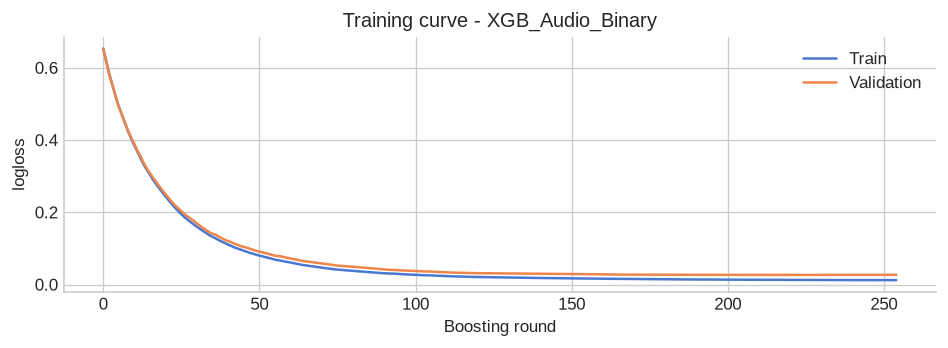

XGB Audio (val): Acc=1.000  Rec=1.000  F1=1.000  AUC=1.000


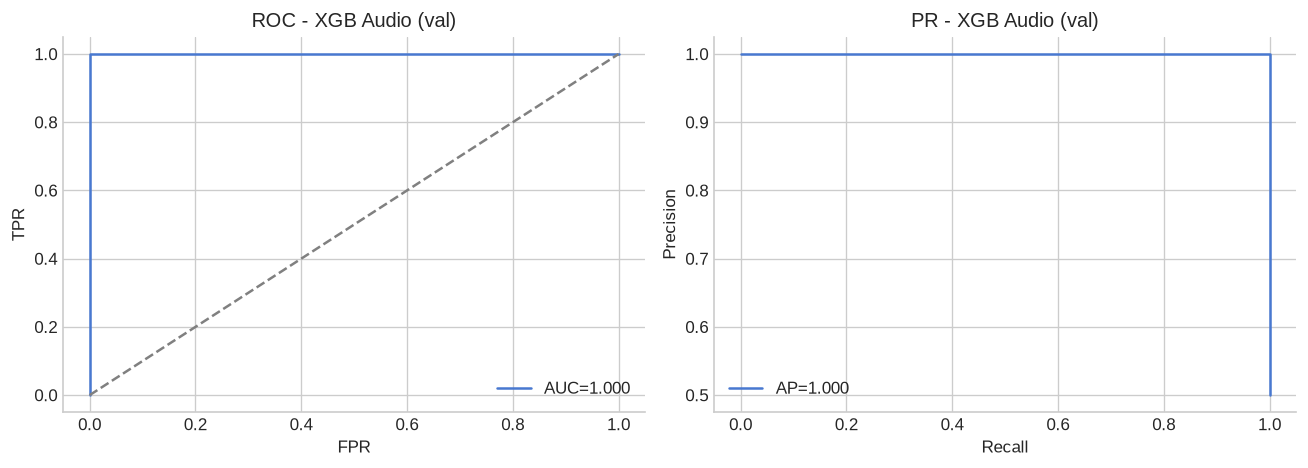

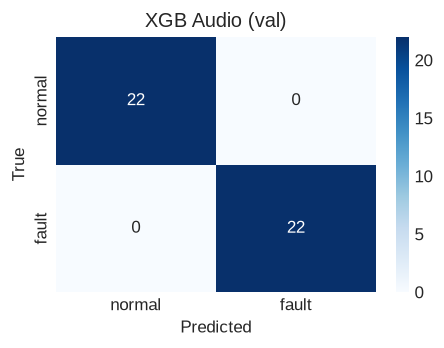

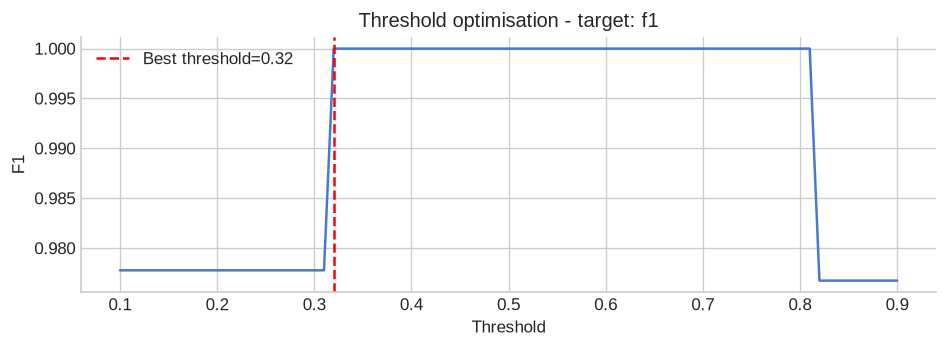

Best validation threshold (audio): 0.32


In [18]:
X_aud_tr = _scale_aud(aud_tr); y_aud_tr = aud_tr["is_fault"].to_numpy()
X_aud_va = _scale_aud(aud_va); y_aud_va = aud_va["is_fault"].to_numpy()
X_aud_te = _scale_aud(aud_te); y_aud_te = aud_te["is_fault"].to_numpy()

xgb_aud_bin, evals_aud_bin = train_binary_xgb(
    X_aud_tr, y_aud_tr, X_aud_va, y_aud_va, "xgb_audio_binary"
)
plot_training_curves(evals_aud_bin, "XGB_Audio_Binary")

xgb_aud_va = evaluate_binary(xgb_aud_bin, X_aud_va, y_aud_va, name="XGB_Aud_Val")
xgb_aud_va["y_true"] = y_aud_va
print(f"XGB Audio (val): Acc={xgb_aud_va['accuracy']:.3f}  "
      f"Rec={xgb_aud_va['recall']:.3f}  F1={xgb_aud_va['f1']:.3f}  "
      f"AUC={xgb_aud_va['roc_auc']:.3f}")
plot_roc_pr(xgb_aud_va, "XGB Audio (val)", "xgb_audio_binary_val")
plot_confusion(xgb_aud_va["confusion_matrix"], ["normal","fault"],
               "XGB Audio (val)", "cm_xgb_audio_binary_val")

best_th_aud = find_best_threshold(xgb_aud_bin, X_aud_va, y_aud_va)
print(f"Best validation threshold (audio): {best_th_aud:.2f}")

---
# 6. Model 3: Multimodal Audio + Vibration Fusion

Feature-level fusion: concatenate scaled vibration and audio feature vectors. This is the simplest and most interpretable fusion strategy - appropriate for a POC with 288 samples. Learned attention fusion would overfit here.

We also compute cross-modal features (ratio of audio RMS to vibration RMS) where physically sensible.

In [19]:
# ── Fused feature matrix ───────────────────────────────────────────────────────

def build_fused_df(vib_df: pd.DataFrame, aud_df: pd.DataFrame) -> pd.DataFrame:
    """Inner-join on sample_id; concatenate feature columns."""
    vfc = [c for c in _feature_cols(vib_df)]
    afc = [c for c in _feature_cols(aud_df)]
    vib_sub = vib_df[["sample_id","fault","is_fault","velocity","source_index"] + vfc]
    aud_sub = aud_df[["sample_id"] + afc]
    fused = vib_sub.merge(aud_sub, on="sample_id", how="inner")
    # Cross-modal: ratio of audio RMS aggregate to vibration Ch1 RMS aggregate
    if "aud_rms_mean" in fused.columns and "vib_ch1_rms_mean" in fused.columns:
        fused["cross_aud_vib_rms_ratio"] = (
            fused["aud_rms_mean"] / (fused["vib_ch1_rms_mean"] + 1e-12)
        )
    return fused

fused_tr = build_fused_df(vib_tr, aud_tr)
fused_va = build_fused_df(vib_va, aud_va)
fused_te = build_fused_df(vib_te, aud_te)

fused_fc = _feature_cols(fused_tr)
fused_scaler = StandardScaler().fit(fused_tr[fused_fc].fillna(0))
joblib.dump(fused_scaler, OUT_DIR / "models" / "fused_scaler.pkl")

def _scale_fused(df: pd.DataFrame) -> np.ndarray:
    return fused_scaler.transform(df[fused_fc].fillna(0)).astype(np.float32)

X_fused_tr = _scale_fused(fused_tr); y_fused_tr = fused_tr["is_fault"].to_numpy()
X_fused_va = _scale_fused(fused_va); y_fused_va = fused_va["is_fault"].to_numpy()
X_fused_te = _scale_fused(fused_te); y_fused_te = fused_te["is_fault"].to_numpy()

print(f"Fused feature matrix: {X_fused_tr.shape[1]} features")

Fused feature matrix: 1486 features


In [20]:
# ── K-fold ensemble on fused features ─────────────────────────────────────────
# With N~288 samples, k-fold ensemble reduces variance without overfitting.
# We train XGB_N_FOLDS models on different folds; final prediction = average probability.

from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=XGB_N_FOLDS, shuffle=True, random_state=42)
fold_models = []
fold_va_preds = np.zeros(len(y_fused_va))

for fold, (tr_idx, oof_idx) in enumerate(skf.split(X_fused_tr, y_fused_tr)):
    Xf_tr, yf_tr = X_fused_tr[tr_idx], y_fused_tr[tr_idx]
    Xf_oof, yf_oof = X_fused_tr[oof_idx], y_fused_tr[oof_idx]

    n_pos = int(yf_tr.sum()); n_neg = len(yf_tr) - n_pos
    fold_clf = build_xgb_binary(n_pos, n_neg, seed=42 + fold)
    if HAS_XGB:
        fold_clf.fit(Xf_tr, yf_tr,
                     eval_set=[(Xf_oof, yf_oof)], verbose=False)
    else:
        fold_clf.fit(Xf_tr, yf_tr)
    fold_models.append(fold_clf)

    # Contribution to validation ensemble prediction
    fold_va_preds += fold_clf.predict_proba(X_fused_va)[:, 1] / XGB_N_FOLDS
    fold_oof_f1 = f1_score(yf_oof, (fold_clf.predict_proba(Xf_oof)[:,1] >= 0.5).astype(int), zero_division=0)
    print(f"  Fold {fold+1} OOF F1 = {fold_oof_f1:.3f}")

# Threshold on ensemble validation probabilities
best_th_fused = float(np.linspace(0.1,0.9,81)[
    np.argmax([f1_score(y_fused_va, (fold_va_preds>=th).astype(int), zero_division=0)
               for th in np.linspace(0.1,0.9,81)])
])
print(f"\nFused ensemble best threshold: {best_th_fused:.2f}")

fused_pred_va = (fold_va_preds >= best_th_fused).astype(int)
fused_f1_va   = f1_score(y_fused_va, fused_pred_va, zero_division=0)
fused_auc_va  = roc_auc_score(y_fused_va, fold_va_preds) if len(np.unique(y_fused_va))>1 else float("nan")
print(f"Fused ensemble (val): F1={fused_f1_va:.3f}  AUC={fused_auc_va:.3f}")

joblib.dump(fold_models, OUT_DIR / "models" / "fused_detector_ensemble.pkl")


def fused_predict_proba(X: np.ndarray) -> np.ndarray:
    """Ensemble mean probability from k-fold models."""
    return np.mean([m.predict_proba(X)[:,1] for m in fold_models], axis=0)

  Fold 1 OOF F1 = 0.976
  Fold 2 OOF F1 = 1.000
  Fold 3 OOF F1 = 0.974
  Fold 4 OOF F1 = 1.000
  Fold 5 OOF F1 = 1.000

Fused ensemble best threshold: 0.10
Fused ensemble (val): F1=1.000  AUC=1.000


In [21]:
import joblib
# Save models, configuration, and data splits to disk
split_data = {
    'vib_tr': vib_tr, 'vib_va': vib_va, 'vib_te': vib_te,
    'aud_tr': aud_tr, 'aud_va': aud_va, 'aud_te': aud_te,
    'train_set': train_set, 'val_set': val_set, 'test_set': test_set
}
joblib.dump(split_data, OUT_DIR / 'features' / '04_splits.pkl')
joblib.dump({'model_vib': xgb_vib_bin, 'model_aud': xgb_aud_bin, 'best_th_fused': best_th_fused}, OUT_DIR / 'models' / '04_trained_models.pkl')
print('Models and validation splits saved.')


Models and validation splits saved.
